# Linear Regression — Theory, Implementation & Evaluation

## 1. What is Linear Regression?

Linear Regression is one of the most fundamental algorithms in all of machine learning and statistics. Before we touch any code, let us build a strong intuition for what it actually does.

Imagine you are a real estate agent. Over the years, you have noticed a pattern — larger houses tend to sell for higher prices. If someone asks you, *"I have a 1,500 sq ft house. What should I price it at?"*, you would mentally draw a line through all the past sales you remember and estimate where 1,500 sq ft falls on that line. That mental line you are drawing? That is Linear Regression.

More formally, Linear Regression tries to find the **best-fitting straight line** through a set of data points. The goal is to model the relationship between one or more **input features** (independent variables) and a **continuous output** (dependent variable).

### The Equation

For Simple Linear Regression (one feature), the equation of the line is:

$$\hat{y} = w_0 + w_1 \cdot x$$

Where:
- $\hat{y}$ is the **predicted value**
- $x$ is the **input feature**
- $w_1$ is the **slope** (also called the weight or coefficient) — it tells us how much $y$ changes when $x$ changes by one unit
- $w_0$ is the **intercept** (also called the bias) — it tells us the value of $y$ when $x = 0$

For Multiple Linear Regression (multiple features), this generalizes to:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

The key idea is the same: we are fitting a linear function to our data.

## 2. How Does It Learn? — The Cost Function

Now, here is the critical question: there are infinitely many lines we could draw through a scatter of points. How do we pick the **best** one?

We need a way to measure how "wrong" a given line is. We do this using a **cost function** (also called a loss function). For Linear Regression, the most common one is the **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Let us break this down:
- For each data point, we compute the difference between the **actual value** ($y_i$) and our **predicted value** ($\hat{y}_i$). This difference is called the **residual** or **error**.
- We **square** each error. Why square? Two reasons: (1) it makes all errors positive so negatives don't cancel out positives, and (2) it penalizes large errors more heavily than small ones.
- We take the **mean** of all squared errors.

The line that gives us the **lowest MSE** is the best-fitting line. The process of finding the weights ($w_0, w_1, \ldots$) that minimize this cost is what we call **training** the model.

### Ordinary Least Squares (OLS)

For Linear Regression, there is actually a closed-form mathematical solution to find the optimal weights. This method is called **Ordinary Least Squares**. It uses calculus (taking the derivative of the cost function, setting it to zero, and solving) to find the exact values of the weights. You do not need to memorize the formula, but it is worth knowing that unlike many ML algorithms, Linear Regression does not require iterative optimization — it can be solved analytically in one shot.

The alternative approach is **Gradient Descent**, where we iteratively adjust the weights in the direction that reduces the cost. Scikit-learn uses OLS by default for standard Linear Regression.

## 3. Assumptions of Linear Regression

Linear Regression is not a magical black box — it comes with certain **assumptions** about the data. If these assumptions are badly violated, the model's predictions and the conclusions we draw from it may be unreliable.

Here are the key ones to keep in mind:

1. **Linearity** — The relationship between the features and the target is approximately linear. If the true relationship is a curve, a straight line will be a poor fit.

2. **Independence of Errors** — The errors (residuals) for different data points should not be correlated with each other. This is especially important in time-series data where consecutive errors can be related.

3. **Homoscedasticity** — The variance of the errors should be roughly constant across all levels of the input features. If the spread of residuals increases or decreases with the predicted value, we call that *heteroscedasticity*, and it is a problem.

4. **Normality of Residuals** — The residuals should be approximately normally distributed. This assumption matters most when we are doing statistical inference (confidence intervals, p-values) rather than pure prediction.

5. **No Multicollinearity** (for multiple regression) — The input features should not be highly correlated with each other. If two features carry nearly the same information, the model has trouble figuring out which one is actually driving the prediction.

We will not formally test all of these today, but as you grow as a data scientist, checking these assumptions becomes an important part of your workflow.

## 4. Setup and Imports

Now that we have the theory grounded, let us move to the practical side. We will start by importing the libraries we need for this lecture. We are going to use NumPy for numerical operations, Pandas for data handling, Matplotlib and Seaborn for visualization, and Scikit-learn for building and evaluating our model.

**Task:** Import the required libraries.

In [1]:
# Import numpy for numerical computations
import numpy as np
# Import pandas for data manipulation
import pandas as pd
# Import matplotlib.pyplot for plotting
import matplotlib.pyplot as plt

# Import seaborn for statistical visualization
import seaborn as sns

# Import train_test_split from sklearn.model_selection

# Import LinearRegression from sklearn.linear_model

# Import mean_squared_error, mean_absolute_error, r2_score from sklearn.metrics

# Optional: set seaborn style for nicer plots

# Optional: set a random seed for reproducibility (e.g., 42)


## 5. Loading and Exploring the Dataset

For this lecture, we will use the **California Housing dataset**. This is a well-known regression dataset that comes built into Scikit-learn. It contains information about housing blocks in California — things like the median income of residents, the average number of rooms, the house age, and so on. Our target variable is the **median house value** for each block (in hundreds of thousands of dollars).

This is a real-world dataset with real patterns and real noise, which makes it an excellent playground for learning regression.

**Task:** Load the California Housing dataset and convert it into a Pandas DataFrame. Take a look at the first few rows.

In [2]:
# Import fetch_california_housing from sklearn.datasets
from sklearn.datasets import fetch_california_housing

# Load the dataset (use as_frame=True for a convenient DataFrame)
houseing = fetch_california_housing(as_frame = True)

housing_df = houseing.frame
# Separate features (X) and target (y)

# Display the first 5 rows of the features DataFrame


In [3]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
final_price = 4.526 * 100000
final_price

452600.0

# California Housing Dataset (scikit-learn)

**Goal:** Predict the median house value of California districts.

| Column | Description |
|------|-------------|
| MedInc | Median income in the district (in tens of thousands of dollars). |
| HouseAge | Median age of houses in the district. |
| AveRooms | Average number of rooms per household. |
| AveBedrms | Average number of bedrooms per household. |
| Population | Total number of people living in the district. |
| AveOccup | Average number of people per household. |
| Latitude | Geographic latitude of the district. |
| Longitude | Geographic longitude of the district. |
| MedHouseVal | Median house value in the district (target variable, in $100,000 units). |

**Dataset size:** 20,640 rows × 9 columns (8 features + 1 target).

### Understanding the Data

Before we build any model, we need to **understand** what we are working with. Let us check the shape of the data, what features are available, and some basic statistics. This step is not optional — skipping it is one of the most common mistakes beginners make.

**Task:** Check the shape, column names, data types, and summary statistics of the dataset.

In [5]:
# Print the shape of the features DataFrame (rows, columns)
housing_df.shape

(20640, 9)

In [6]:
# Print all column names
housing_df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [7]:
# Check data types and non-null counts using .info()
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
# Display summary statistics using .describe()
housing_df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
X = houseing.data
y = houseing.target

In [10]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [11]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

### Checking for Missing Values

Real-world data is messy. One of the first things we always check is whether there are any missing values. Missing values can break our model or silently make it worse. Let us check this now.

**Task:** Check if there are any missing values in the dataset.

In [12]:
# Check for missing values in the features DataFrame
# Hint: use .isnull().sum()
print(X.isnull().sum())


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [13]:
print(y.isnull().sum())

0


## 6. Exploratory Data Analysis (EDA)

Before we jump into modeling, let us **visualize** the data. Visualization helps us spot patterns, outliers, and relationships that raw numbers alone cannot reveal. We want to understand which features seem to have a relationship with the target variable.

### 6.1 Distribution of the Target Variable

Let us first look at how our target variable (median house value) is distributed. Is it normally distributed? Is it skewed? Are there any caps or cutoffs? This tells us a lot about what our model is trying to predict.

**Task:** Plot the distribution of the target variable.

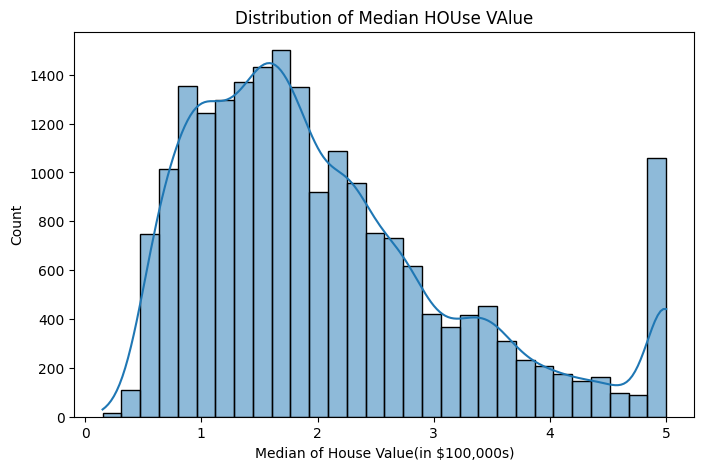

In [14]:
# Create a histogram (with KDE) of the target variable y
# Use plt.figure(figsize=(8, 5)) for a good size
# Add a title: 'Distribution of Median House Value'
# Add axis labels
# Show the plot

plt.figure(figsize=(8,5))
sns.histplot(
    y,
    kde = "True",
    bins = 30,
)
plt.title("Distribution of Median HOUse VAlue")
plt.xlabel("Median of House Value(in $100,000s)")
plt.show()

### 6.2 Correlation Analysis

Next, let us look at how each feature correlates with the target. Correlation gives us a quick numerical summary of the strength and direction of the linear relationship between two variables. A correlation close to +1 or -1 means a strong linear relationship, while a value near 0 means little to no linear relationship.

**Task:** Compute and visualize the correlation matrix using a heatmap.

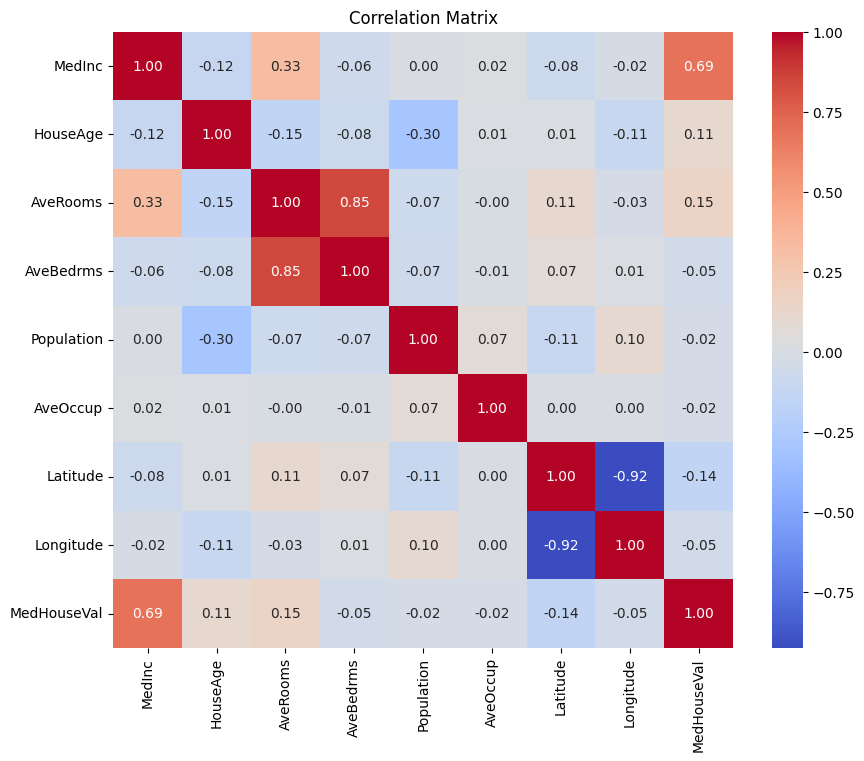

In [15]:
# Create a combined DataFrame with features and target for correlation
# Hint: use pd.concat or just add y as a column to a copy of X

# Compute the correlation matrix using .corr()

# Plot a heatmap using seaborn
# Use plt.figure(figsize=(10, 8))
# Use sns.heatmap() with annot=True, fmt='.2f', and cmap='coolwarm'
# Add a title: 'Correlation Matrix'
# Show the plot
corr_matrix = housing_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt ='.2f',
    cmap = 'coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

### 6.3 Scatter Plots — Feature vs Target

Correlation gives us a number, but a scatter plot gives us the full picture. Let us plot a couple of the most correlated features against the target to visually confirm the linear relationship.

**Task:** Create scatter plots of the top 2 most correlated features against the target variable.

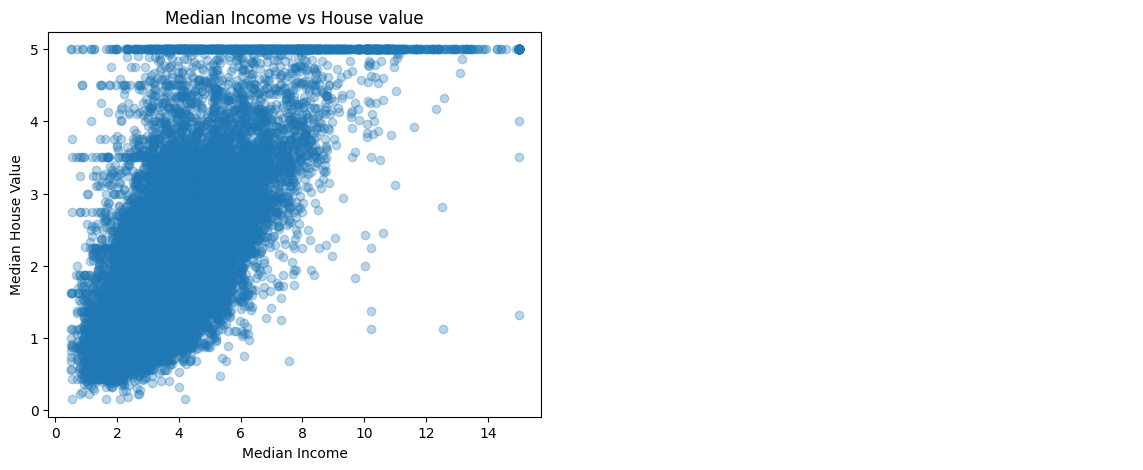

In [16]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].scatter(housing_df['MedInc'], housing_df['MedHouseVal'], alpha=0.3)
axes[0].set_title("Median Income vs House value")
axes[0].set_xlabel("Median Income")
axes[0].set_ylabel("Median House Value")

axes[1].axis("off")
plt.show()

## 7. Data Preparation — Train/Test Split

This is a critical step that many beginners underestimate. We **never** evaluate a model on the same data it was trained on. Why? Because the model has already "seen" that data and may have memorized patterns (including noise). This would give us an overly optimistic view of how well the model actually generalizes to new, unseen data.

Instead, we split our data into two parts:
- **Training set** (~80%) — used to train (fit) the model
- **Test set** (~20%) — held out and used **only** to evaluate the model's performance

**Task:** Split the data into training and test sets.

In [17]:
# Split X and y into training and test sets
# Use test_size=0.2 and random_state=42 for reproducibility
# Print the shape of X_train, X_test, y_train, y_test to confirm the split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 42  
)

In [18]:
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train ratio:  {X_train.shape[0] / len(X):.1%}")
print(f"Test ratio:   {X_test.shape[0] / len(X):.1%}")

Training set: 16512 samples
Test set:     4128 samples
Train ratio:  80.0%
Test ratio:   20.0%


## 8. Building the Linear Regression Model

Now we get to the exciting part — actually building and training the model. With Scikit-learn, this is remarkably simple: we create a `LinearRegression` object and call `.fit()` on our training data. Under the hood, Scikit-learn uses the Ordinary Least Squares method to find the optimal weights.

**Task:** Create a Linear Regression model and train it on the training data.

In [19]:
# Create a LinearRegression model instance
# Fit (train) the model on X_train and y_train
# Print a confirmation message that training is complete

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print("Model Training COmplete")

Model Training COmplete


In [20]:
model.coef_

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

In [21]:
model.intercept_

np.float64(-37.02327770606405)

### Inspecting the Learned Parameters

Unlike some complex ML models, Linear Regression is fully **interpretable**. After training, we can look at exactly what the model learned — the coefficients (weights) and the intercept (bias). Each coefficient tells us: *"For a one-unit increase in this feature, the predicted house value changes by this much, holding all other features constant."*

This interpretability is one of the biggest strengths of Linear Regression.

**Task:** Extract and display the model's coefficients and intercept.

In [22]:
# Access the model's coefficients using model.coef_
# Access the model's intercept using model.intercept_
# Create a neat display: for each feature name in X.columns,
# print the feature name alongside its coefficient
# Hint: use zip(X.columns, model.coef_)
# Print the intercept separately

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature} : {coef:+.4f}")
    
    
print(f"Intercept:  {model.intercept_:+.4f}")


MedInc : +0.4487
HouseAge : +0.0097
AveRooms : -0.1233
AveBedrms : +0.7831
Population : -0.0000
AveOccup : -0.0035
Latitude : -0.4198
Longitude : -0.4337
Intercept:  -37.0233


y^ = -37.0.233 + 0.4487 * MedInc + 0.0097 * HouseAge .........-0.4337 * Longitude

## 9. Making Predictions

Now that the model is trained, let us use it to make predictions on the **test set** — data the model has never seen before. This is the moment of truth: how well does our line generalize to new data?

**Task:** Use the trained model to predict on the test set.

In [23]:
# Use model.predict() on X_test to get predictions

# Display the first 10 predicted values alongside the first 10 actual values
# Hint: create a small DataFrame with columns 'Actual' and 'Predicted'

y_pred = model.predict(X_test)

In [24]:
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

In [25]:
comparison = pd.DataFrame(
    {
        'Actual' : y_test.values[:10],
        'Prediction' : y_pred[:10],
        'Error': y_test.values[:10] - y_pred[:10]
    }
)

In [26]:
comparison

,Actual,Prediction,Error
0,0.47700,0.719123,-0.242123
1,0.45800,1.764017,-1.306017
2,5.00001,2.709659,2.290351
3,2.18600,2.838926,-0.652926
4,2.78000,2.604657,0.175343
5,1.58700,2.011754,-0.424754
6,1.98200,2.645500,-0.663500
7,1.57500,2.168755,-0.593755
8,3.40000,2.740746,0.659254
9,4.46600,3.915615,0.550385


## 10. Model Evaluation

Making predictions is nice, but we need to **quantify** how good those predictions actually are. We will use three standard regression evaluation metrics. Let us understand each one before computing them.

### 10.1 Mean Absolute Error (MAE)

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

MAE is the simplest metric. It computes the average of the **absolute** differences between actual and predicted values. It tells you, on average, how far off your predictions are — in the same units as the target variable. It is easy to interpret: an MAE of 0.5 means your predictions are off by about 0.5 (in this case, $50,000) on average.

### 10.2 Mean Squared Error (MSE) and Root Mean Squared Error (RMSE)

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

$$RMSE = \sqrt{MSE}$$

MSE squares the errors before averaging, which means it penalizes large errors more heavily. RMSE takes the square root of MSE to bring it back to the original units. RMSE is generally preferred for reporting because it is in the same scale as the target.

### 10.3 R² Score (Coefficient of Determination)

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

R² tells us what **proportion** of the variance in the target variable is explained by our model. It ranges from $-\infty$ to 1:
- **R² = 1** means the model perfectly predicts the target
- **R² = 0** means the model is no better than simply predicting the mean of the target for every data point
- **R² < 0** means the model is worse than the mean baseline (very bad)

**Task:** Compute MAE, MSE, RMSE, and R² on the test set predictions.

In [27]:
# Compute Mean Absolute Error (MAE)
# Compute Mean Squared Error (MSE)
# Compute Root Mean Squared Error (RMSE)
# Hint: take the square root of MSE using np.sqrt()
# Compute R² Score
# Print all four metrics neatly with labels
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

  MAE  : 0.5332
  MSE  : 0.5559
  RMSE : 0.7456
  R²   : 0.5758


In [28]:
print(f"\nInterpretation:")
print(f"  On average, predictions are off by ~${mae * 100000:,.0f}")
print(f"  The model explains {r2:.1%} of the variance in house prices")


Interpretation:
  On average, predictions are off by ~$53,320
  The model explains 57.6% of the variance in house prices



## 11. Visualizing Model Performance

Numbers are important, but plots help us see *where* and *how* the model is succeeding or failing. We will create two key diagnostic plots.

### 11.1 Actual vs Predicted Plot

This is the most common regression diagnostic. We plot the actual values on the x-axis and the predicted values on the y-axis. If the model were perfect, all points would lie exactly on a 45-degree diagonal line (where actual = predicted). The more the points scatter away from this line, the worse the model is doing.

**Task:** Create an Actual vs Predicted scatter plot.

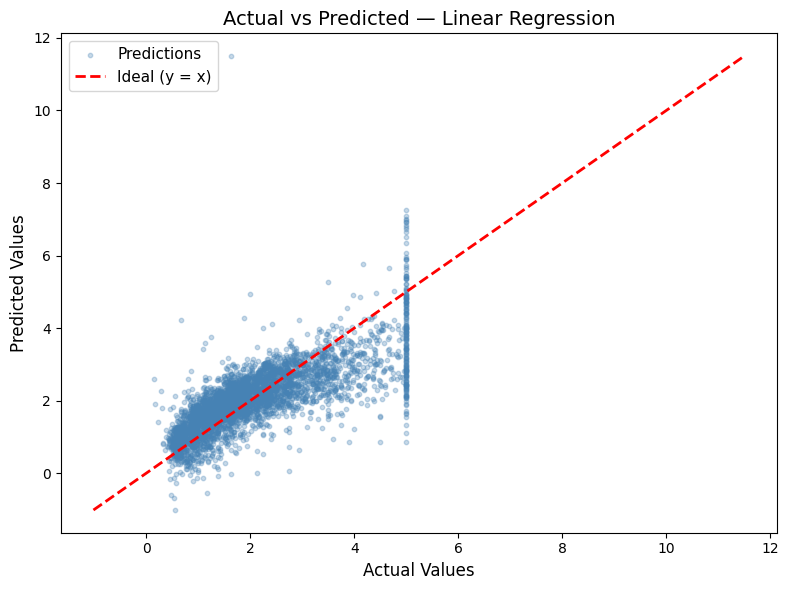

In [29]:
# Create a figure with figsize=(8, 6)

# Scatter plot: y_test (actual) on x-axis, y_pred (predicted) on y-axis
# Use alpha=0.3 and a descriptive label

# Plot the ideal diagonal line (y = x) in red with a dashed style
# Hint: plot a line from [min_val, max_val] to [min_val, max_val]

# Add title: 'Actual vs Predicted — Linear Regression'
# Add x-label: 'Actual Values'
# Add y-label: 'Predicted Values'
# Add legend
# Show the plot

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue', label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal (y = x)')

plt.title('Actual vs Predicted — Linear Regression', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 11.2 Residuals Plot

The residuals plot shows the **errors** (actual - predicted) on the y-axis against the predicted values on the x-axis. Ideally, the residuals should be randomly scattered around zero with no visible pattern. If you see a pattern (like a curve, or a funnel shape), it means the model is systematically getting something wrong.

**Task:** Create a residuals plot.

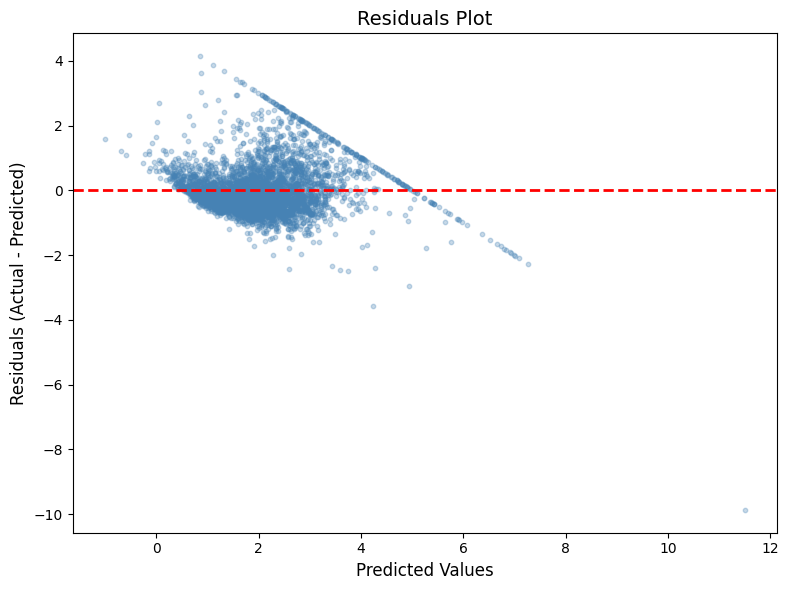

In [30]:
# Compute residuals: y_test - y_pred

# Create a figure with figsize=(8, 6)

# Scatter plot: y_pred on x-axis, residuals on y-axis
# Use alpha=0.3

# Draw a horizontal line at y=0 in red with dashed style
# Hint: use plt.axhline(y=0, ...)

# Add title: 'Residuals Plot'
# Add x-label: 'Predicted Values'
# Add y-label: 'Residuals'
# Show the plot


residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residuals Plot', fontsize=14)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.tight_layout()
plt.show()

### 11.3 Distribution of Residuals

Let us also check if the residuals are approximately normally distributed. This is one of the assumptions of Linear Regression, and checking it is straightforward with a histogram.

**Task:** Plot the distribution of residuals.

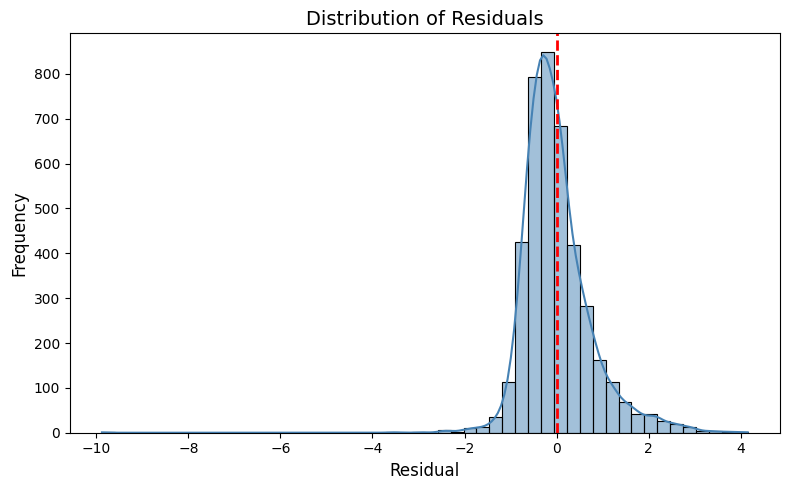

Residuals — Mean: 0.0035, Std: 0.7457


In [31]:
# Create a figure with figsize=(8, 5)

# Plot a histogram of the residuals with KDE
# Use bins=50

# Add a vertical line at x=0 in red
# Hint: use plt.axvline(x=0, ...)

# Add title: 'Distribution of Residuals'
# Add x-label: 'Residual'
# Show the plot

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=50, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.title('Distribution of Residuals', fontsize=14)
plt.xlabel('Residual', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Residuals — Mean: {residuals.mean():.4f}, Std: {residuals.std():.4f}")


## 12. Comparing Train vs Test Performance

One last important check: we need to compare how the model performs on the **training set** versus the **test set**. This helps us diagnose whether the model is **overfitting** (memorizing the training data) or **underfitting** (too simple to capture the pattern).

- If train R² is **much higher** than test R² → the model may be overfitting
- If both are **similarly low** → the model may be underfitting
- If both are **similar and reasonably high** → the model generalizes well

For Linear Regression, overfitting is rare (it is a simple model), so we usually see underfitting.

**Task:** Compute and compare R² on both the training set and the test set.

In [32]:
# Predict on the training set using model.predict(X_train)

# Compute R² for the training set

# Compute R² for the test set (we already have this, but compute again for clarity)

# Print both R² scores side by side
# Interpret: are they similar? Is the model overfitting or underfitting?
y_train_pred = model.predict(X_train)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 45)
print("  TRAIN vs TEST COMPARISON")
print("=" * 45)
print(f"  {'Metric':<12} {'Train':>10} {'Test':>10}")
print(f"  {'-'*12} {'-'*10} {'-'*10}")
print(f"  {'R²':<12} {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"  {'RMSE':<12} {train_rmse:>10.4f} {test_rmse:>10.4f}")
print("=" * 45)

gap = train_r2 - test_r2
print(f"\n  R² Gap (Train - Test): {gap:.4f}")
if gap < 0.05:
    print("  → The scores are close. No significant overfitting.")
    print("  → Both are moderate, suggesting the model is underfitting.")
    print("  → A more complex model may capture additional patterns.")
elif gap < 0.15:
    print("  → Some gap. Mild overfitting possible.")
else:
    print("  → Large gap. The model is likely overfitting.")

  TRAIN vs TEST COMPARISON
  Metric            Train       Test
  ------------ ---------- ----------
  R²               0.6126     0.5758
  RMSE             0.7197     0.7456

  R² Gap (Train - Test): 0.0368
  → The scores are close. No significant overfitting.
  → Both are moderate, suggesting the model is underfitting.
  → A more complex model may capture additional patterns.
